In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/competitions/rsna-knee-abnormality-detection"

train = pd.read_csv(DATA_DIR + "/train.csv")
train_series = pd.read_csv(DATA_DIR + "/train_series.csv")

# Use first 500 studies
train_500 = train.head(500)

print("Studies:", len(train_500))

Studies: 500


In [2]:
selected_series = train_series[
    train_series["StudyInstanceUID"].isin(
        train_500["StudyInstanceUID"]
    )
]

print("Number of series:", selected_series["SeriesInstanceUID"].nunique())
print("Number of studies with series:",
      selected_series["StudyInstanceUID"].nunique())

Number of series: 2792
Number of studies with series: 500


In [3]:
series_per_study = selected_series.groupby(
    "StudyInstanceUID"
).size()

print(series_per_study.describe())

count    500.000000
mean       5.584000
std        1.450224
min        4.000000
25%        5.000000
50%        5.000000
75%        6.000000
max       12.000000
dtype: float64


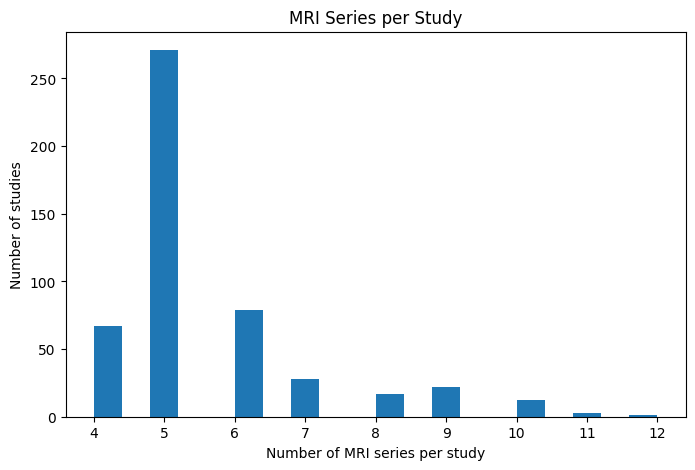

In [4]:
plt.figure(figsize=(8,5))

plt.hist(series_per_study, bins=20)

plt.xlabel("Number of MRI series per study")
plt.ylabel("Number of studies")
plt.title("MRI Series per Study")

plt.show()

In [5]:
label_cols = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

label_counts = train_500[label_cols].sum().sort_values()

print(label_counts)

MCL                 0.0
Lateral OA          0.0
Contusion           0.0
Baker's             0.0
Fracture            0.0
Medial OA           1.0
Lateral Meniscus    1.0
ACL                 1.0
Medial Meniscus     2.0
Effusion            2.0
Synovitis           2.0
PF OA               3.0
dtype: float64


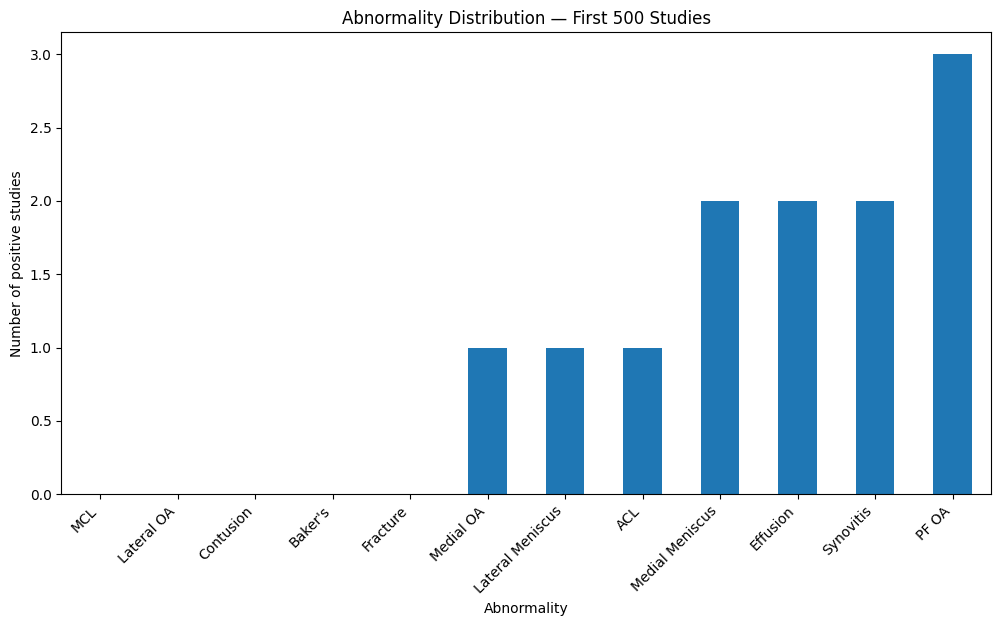

In [6]:
plt.figure(figsize=(12,6))

label_counts.plot(kind="bar")

plt.xlabel("Abnormality")
plt.ylabel("Number of positive studies")
plt.title("Abnormality Distribution — First 500 Studies")
plt.xticks(rotation=45, ha="right")

plt.show()

In [7]:
print(selected_series.columns.tolist())

['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


In [8]:
plane_counts = selected_series["Anatomical_Plane"].value_counts()

print(plane_counts)

Anatomical_Plane
Sagittal    1139
Coronal      987
Axial        666
Name: count, dtype: int64


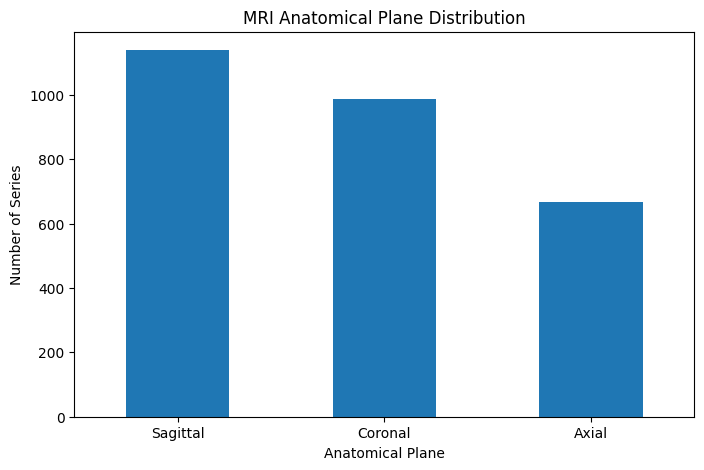

In [9]:
plt.figure(figsize=(8,5))

plane_counts.plot(kind="bar")

plt.xlabel("Anatomical Plane")
plt.ylabel("Number of Series")
plt.title("MRI Anatomical Plane Distribution")

plt.xticks(rotation=0)
plt.show()

In [10]:
print("Fluid Sensitive:")
print(selected_series["Fluid_Sensitive"].value_counts())

print("\nFat Suppression:")
print(selected_series["Fat_Suppression"].value_counts())

Fluid Sensitive:
Fluid_Sensitive
1    1605
0    1187
Name: count, dtype: int64

Fat Suppression:
Fat_Suppression
1    1605
0    1187
Name: count, dtype: int64


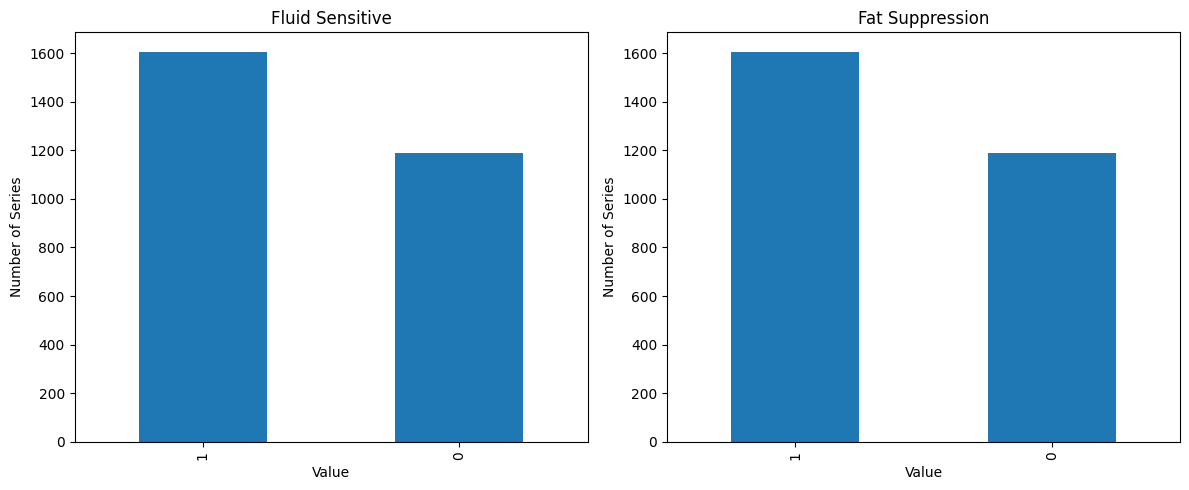

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

selected_series["Fluid_Sensitive"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Fluid Sensitive")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Number of Series")

selected_series["Fat_Suppression"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Fat Suppression")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Number of Series")

plt.tight_layout()
plt.show()

In [12]:
import os
import pydicom
import matplotlib.pyplot as plt

# Select first study
study_id = train_500["StudyInstanceUID"].iloc[0]

# Get its series
study_series = selected_series[
    selected_series["StudyInstanceUID"] == study_id
]

print("Study:", study_id)
display(study_series)

Study: 1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [13]:
# Select first series
series_id = study_series["SeriesInstanceUID"].iloc[0]

series_path = os.path.join(
    DATA_DIR,
    "train_series",
    study_id,
    series_id
)

files = [
    f for f in os.listdir(series_path)
    if f.endswith(".dcm")
]

print("Series:", series_id)
print("Number of DICOM slices:", len(files))

Series: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772
Number of DICOM slices: 22


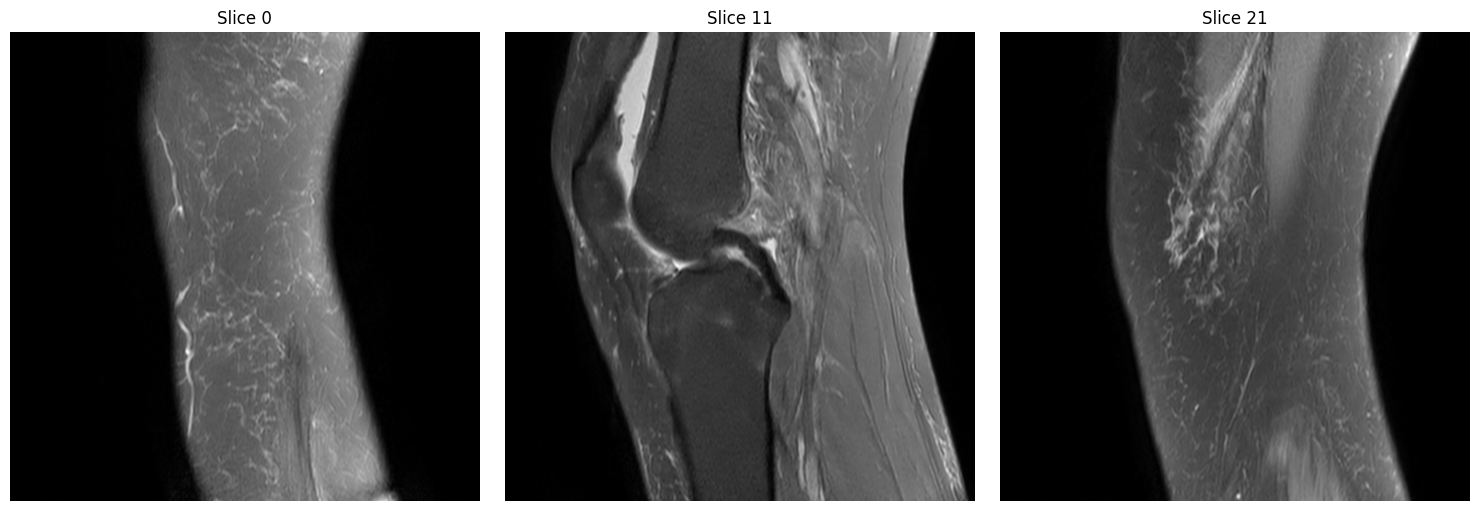

In [14]:
slices = []

for file in files:
    ds = pydicom.dcmread(
        os.path.join(series_path, file)
    )
    slices.append(ds)

# Order by slice position
slices.sort(
    key=lambda x: float(x.ImagePositionPatient[2])
)

# Display 3 slices
indices = [
    0,
    len(slices) // 2,
    len(slices) - 1
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, indices):
    ax.imshow(slices[idx].pixel_array, cmap="gray")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()